In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from difflib import get_close_matches

INVENTORY_PATH = "/Users/cooperzvegintzov/Library/Mobile Documents/com~apple~CloudDocs/Documents/ChakraTech/Final/Inventory.csv"
IMPACT_FACTORS_PATH = "/Users/cooperzvegintzov/Library/Mobile Documents/com~apple~CloudDocs/Documents/ChakraTech/Final/Impactfactors.csv"


In [2]:
def norm(s: str) -> str:
    if pd.isna(s): return ""
    s = str(s)
    s = (s.replace("\u202f"," ").replace("\u00a0"," ")
           .replace("\u2011","-").replace("\u2013","-").replace("\u2014","-"))
    return re.sub(r"\s+"," ",s).strip().lower()

def find_col(df: pd.DataFrame, tokens) -> str:
    for c in df.columns:
        cl = c.lower()
        if all(t.lower() in cl for t in tokens):
            return c
    raise KeyError(f"Column with tokens {tokens} not found. Columns: {list(df.columns)}")


In [3]:
inv_raw = pd.read_csv(INVENTORY_PATH)
imp_raw = pd.read_csv(IMPACT_FACTORS_PATH)

display(inv_raw.head(8))
display(imp_raw.head(8))


,Raw Material,Value,Unit
0,Palm Oil,1020,kg/t-PHA
1,NaN,NaN,NaN
2,Yeast,13.7,kg/t-PHA
3,Glucose,2,kg/t-PHA
4,Sodium Phosphate,3,kg/t-PHA
5,Citric Acid,31.5,kg/t-PHA
6,Ammonia liquid,14.8,kg/t-PHA
7,Sodium Hydroxide,125.4,kg/t-PHA


,Impact Category Units,kg CO2-eq
0,Palm Oil,4.350
1,Yeast,1.250
2,Glucose,1.760
3,Sodium Phosphate,2.130
4,Citric Acid,4.700
5,Ammonia liquid,0.724
6,Sodium Hydroxide,0.683
7,Ammonia Sulphate,2.620


In [4]:
cat_col = find_col(imp_raw, ["impact","category"])
kg_col  = find_col(imp_raw, ["co2","kg"])

EXCLUDE = {"incineration","landfill","composting","recycling"}
imp = imp_raw[~imp_raw[cat_col].astype(str).str.strip().str.lower().isin(EXCLUDE)].copy()

imp["_key"] = imp[cat_col].map(norm)
imp[kg_col] = pd.to_numeric(imp[kg_col], errors="coerce")

factor_lookup = dict(zip(imp["_key"], imp[kg_col]))
factor_keys = list(factor_lookup.keys())
print(f"Impact-factor rows kept: {len(imp)}")


Impact-factor rows kept: 19


In [5]:
SECTION_HEADERS = ["Electricity consumption", "Steam", "Water", "Transportation"]
SECTION_HEADERS_N = [norm(x) for x in SECTION_HEADERS]

rows, current_section = [], None
for _, r in inv_raw.iterrows():
    name = str(r.get("Raw Material","")).strip()
    val  = pd.to_numeric(r.get("Value", np.nan), errors="coerce")
    unit = r.get("Unit","")

    if norm(name) in SECTION_HEADERS_N and pd.isna(val):
        current_section = name
        continue
    if not name or pd.isna(val):
        continue

    rows.append({"Item": name, "Section": current_section, "Value": val, "Unit": unit})

inv = pd.DataFrame(rows).reset_index(drop=True)

def assign_category(row):
    if pd.notna(row["Section"]):
        return row["Section"]
    if norm(row["Item"]) == norm("Palm oil"):
        return "Palm oil"
    return "Chemicals"   # roll all other raw materials together

inv["Category"] = inv.apply(assign_category, axis=1)
display(inv.head(12))


,Item,Section,Value,Unit,Category
0,Palm Oil,None,1020.0,kg/t-PHA,Palm oil
1,Yeast,None,13.7,kg/t-PHA,Chemicals
2,Glucose,None,2.0,kg/t-PHA,Chemicals
3,Sodium Phosphate,None,3.0,kg/t-PHA,Chemicals
4,Citric Acid,None,31.5,kg/t-PHA,Chemicals
5,Ammonia liquid,None,14.8,kg/t-PHA,Chemicals
6,Sodium Hydroxide,None,125.4,kg/t-PHA,Chemicals
7,Ammonia Sulphate,None,12.4,kg/t-PHA,Chemicals
8,Potassium Phosphate,None,4.8,kg/t-PHA,Chemicals
9,Enzyme,None,2.4,kg/t-PHA,Chemicals


In [6]:
def factor_key_for_row(row):
    cat_n, item_n = norm(row["Category"]), norm(row["Item"])

    if cat_n == norm("electricity consumption"):
        key = norm("Electricity consumption")
    elif cat_n == norm("steam"):
        key = norm("Steam")
    elif cat_n == norm("water"):
        key = norm("Water")
    elif cat_n == norm("transportation"):
        if item_n in (norm("land"), norm("sea")):
            key = norm(f"Transportation - {row['Item'].title()}")
        else:
            key = norm("Transportation")
    elif cat_n == norm("palm oil"):
        key = norm("Palm oil")
    else:
        key = item_n  # chemicals: use specific item name

    if key in factor_lookup:
        return key
    m = get_close_matches(key, factor_keys, n=1, cutoff=0.85)
    return m[0] if m else None

inv["_factor_key"] = inv.apply(factor_key_for_row, axis=1)
inv["Factor (kg CO2-eq / unit)"] = inv["_factor_key"].map(factor_lookup)

unmapped = inv[inv["Factor (kg CO2-eq / unit)"].isna()][["Item","Category"]].drop_duplicates()
if len(unmapped):
    print("⚠️ Unmapped items — add/rename in Impactfactors.csv or tweak mapping:")
    display(unmapped)
else:
    print("✅ All items matched to impact factors.")


✅ All items matched to impact factors.


In [7]:
# Categories in your inventory that are per-ton PHA and need /1000
PER_TON_CATS = ["Palm oil","Electricity consumption","Transportation","Water","Chemicals"]
# Categories already per-kg (leave as-is)
PER_KG_CATS  = ["Steam","Direct emission","Waste water"]  # extend if needed

def compute_impact(row):
    val = row["Value"] * row["Factor (kg CO2-eq / unit)"]
    if row["Category"] in PER_TON_CATS:
        return val / 1000.0     # convert per ton → per kg
    else:
        return val              # already per kg

inv["Impact (kg CO2-eq)"] = inv.apply(compute_impact, axis=1)

matched = inv.dropna(subset=["Impact (kg CO2-eq)"]).copy()
by_cat = matched.groupby("Category", as_index=False)["Impact (kg CO2-eq)"].sum()
print("Per-kg contributions (top):")
display(by_cat.sort_values("Impact (kg CO2-eq)", ascending=False).head(10))

print("Steam rows check:")
display(inv.loc[inv["Category"].eq("Steam"), ["Item","Value","Factor (kg CO2-eq / unit)","Impact (kg CO2-eq)"]])


Per-kg contributions (top):


,Category,Impact (kg CO2-eq)
2,Palm oil,4.437000
3,Steam,1.212000
1,Electricity consumption,0.998256
0,Chemicals,0.493434
4,Transportation,0.121890
5,Water,0.031253


Steam rows check:


,Item,Value,Factor (kg CO2-eq / unit),Impact (kg CO2-eq)
17,Fermentation,1.30,0.3,0.390
18,Extraction,2.70,0.3,0.810
19,Pelleting,0.04,0.3,0.012


In [8]:
# Hard-coded additional categories (all in per-kg CO2-eq units)
extras = {
    "Methane capture": -1.59,   # negative
    "CO2 uptake": -2.06,        # negative
    "Direct emission": 0.46,    # fixed value
    "End of Life": 2.10,        # fixed value
}

extras_df = (
    pd.Series(extras, name="Impact (kg CO2-eq)")
      .rename_axis("Category")
      .reset_index()
)

cat_plus = (
    pd.concat([by_cat, extras_df], ignore_index=True)
      .groupby("Category", as_index=False)["Impact (kg CO2-eq)"].sum()
)

display(cat_plus.sort_values("Impact (kg CO2-eq)", ascending=False))


,Category,Impact (kg CO2-eq)
6,Palm oil,4.437000
4,End of Life,2.100000
7,Steam,1.212000
3,Electricity consumption,0.998256
1,Chemicals,0.493434
2,Direct emission,0.460000
8,Transportation,0.121890
9,Water,0.031253
5,Methane capture,-1.590000
0,CO2 uptake,-2.060000


In [9]:
ordered_categories = [
    "Palm oil","Methane capture","Transportation","Electricity consumption",
    "Steam","Water","Chemicals","Direct emission","Waste water","CO2 uptake","End of Life"
]
xlabels = [
    "Palm oil","Methane capture","Transport","Electricity",
    "Steam","Water","Chemicals","Direct emission","Waste water","CO₂ uptake","End of Life"
]

vals = [cat_plus.loc[cat_plus["Category"].eq(c), "Impact (kg CO2-eq)"].sum()
        for c in ordered_categories]
vals = [0.0 if pd.isna(v) else float(v) for v in vals]

bottoms = [0.0]
for i in range(1, len(vals)):
    bottoms.append(bottoms[-1] + vals[i-1])

subtotal = sum(vals)
print(f"Sanity: Palm oil={vals[0]:.2f}, Electricity={vals[3]:.2f}, Steam={vals[4]:.4f}, Subtotal={subtotal:.2f}")


Sanity: Palm oil=4.44, Electricity=1.00, Steam=1.2120, Subtotal=6.20


Saved: pha_waterfall.png


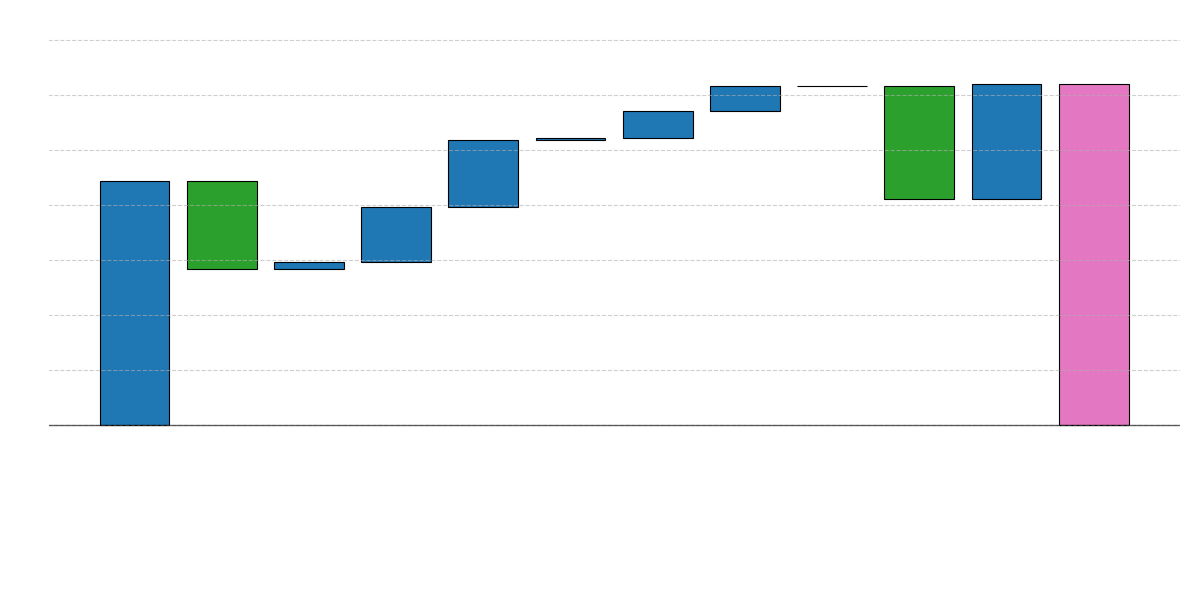

In [13]:
fig_pha, ax = plt.subplots(figsize=(12, 6))

for i, (v, b) in enumerate(zip(vals, bottoms)):
    ax.bar(i, v, bottom=b, color=("tab:blue" if v >= 0 else "tab:green"),
           edgecolor="black", linewidth=0.8)

# Subtotal bar
ax.bar(len(vals), subtotal, color="tab:pink", edgecolor="black", linewidth=0.8)

xlabels_plot = xlabels + ["Subtotal"]
ax.set_xticks(range(len(xlabels_plot)))
ax.set_xticklabels(xlabels_plot, rotation=45, ha="right")

ax.set_ylabel("Carbon footprint (kgCO₂-eq / kg-polymer)")
ax.set_title("Bio-based polymer (PHA)")

# Zero line + grid
ax.axhline(0, linewidth=1, color="black", alpha=0.6)
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Value labels
tops = [b+v for b, v in zip(bottoms, vals)]
pad = 0.08 * max(1.0, max(abs(min([0]+bottoms+tops)), abs(max([0]+bottoms+tops))))
for i, v in enumerate(vals + [subtotal]):
    y = (tops[i] if i < len(tops) else subtotal)
    ax.text(i, y + (pad if v >= 0 else -pad), f"{v:.2f}",
            ha="center", va=("bottom" if v >= 0 else "top"), fontsize=9, color="white")

# Nice y-limits so nothing clips
ymin = min(0, *(bottoms + tops))
ymax = max(0, *(bottoms + tops))
ax.set_ylim(ymin - 0.15*abs(ymin if ymin else ymax), ymax + 0.15*abs(ymax))

# Make all text white for dark background
ax.title.set_color("white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# If you want the spines (box edges) white too
for spine in ax.spines.values():
    spine.set_color("white")


fig_pha.tight_layout()

# Save the SAME figure you plotted
out_path = "pha_waterfall.png"
fig_pha.savefig(out_path, dpi=300, bbox_inches="tight", transparent=True)
print("Saved:", out_path)

plt.show()
